# Task 4 (Bonus): Human vs Machine

This notebook generates visualizations for the Human vs Machine analysis. For detailed findings and case studies, see `report/Human vs Machine.md`.

We identify systematic differences between human and LLM performance:
- **Easy Human, Hard LLM**: Sorting puzzles (8-24% LLM success, ~100% human)
- **Easy for Both**: Concatenation puzzles (87% LLM success)
- **Hard for Both**: Long-chain puzzles (6% LLM success)


In [16]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Professional styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titleweight'] = 'bold'

base_path = Path('..')
results_dir = base_path / 'results'
puzzles_dir = base_path / 'data' / 'puzzles'
solutions_dir = base_path / 'data' / 'solutions'

with open(base_path / 'data' / 'metadata.json') as f:
    metadata = {m['problem_id']: m for m in json.load(f)}

# Aggregate success rates per puzzle
puzzle_success = defaultdict(lambda: {'correct': 0, 'total': 0, 'responses': []})

for summary_file in results_dir.glob('*_summary.json'):
    if 'compound' in summary_file.name:
        continue
    with open(summary_file) as f:
        data = json.load(f)
    for r in data.get('results', []):
        pid = r['problem_id']
        puzzle_success[pid]['total'] += 1
        puzzle_success[pid]['responses'].append(r)
        if r['is_correct']:
            puzzle_success[pid]['correct'] += 1

for pid in puzzle_success:
    puzzle_success[pid]['rate'] = puzzle_success[pid]['correct'] / puzzle_success[pid]['total']


Visualizes how different puzzle generators (sorting, concatenation, backward) affect LLM performance.


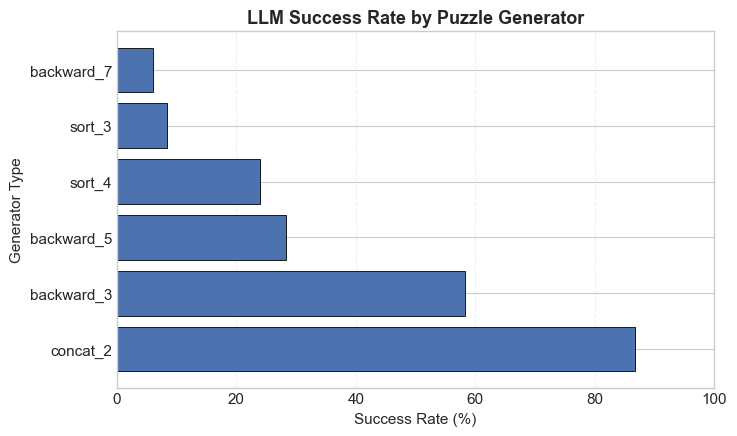

 Generator  Success Rate (%)  Total Evaluations  Unique Puzzles
  concat_2         86.666667                 45               3
backward_3         58.333333                 60               4
backward_5         28.333333                 60               4
    sort_4         24.000000                 75               5
    sort_3          8.333333                 60               4
backward_7          6.111111                180              12


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# -----------------------------
# Aggregate by generator
# -----------------------------
gen_stats = defaultdict(lambda: {'correct': 0, 'total': 0, 'puzzles': set()})

for pid, data in puzzle_success.items():
    gen = metadata.get(pid, {}).get('generator', 'unknown')
    gen_stats[gen]['correct'] += data['correct']
    gen_stats[gen]['total'] += data['total']
    gen_stats[gen]['puzzles'].add(pid)

gen_df = pd.DataFrame([
    {
        'Generator': gen,
        'Success Rate (%)': d['correct'] / d['total'] * 100,
        'Total Evaluations': d['total'],
        'Unique Puzzles': len(d['puzzles'])
    }
    for gen, d in gen_stats.items()
]).sort_values('Success Rate (%)', ascending=False)

# -----------------------------
# Visualization (single plot)
# -----------------------------
fig, ax = plt.subplots(figsize=(7.5, 4.5))

ax.barh(
    gen_df['Generator'],
    gen_df['Success Rate (%)'],
    color='#4C72B0',
    edgecolor='black',
    linewidth=0.6
)

ax.set_xlabel('Success Rate (%)')
ax.set_ylabel('Generator Type')
ax.set_title('LLM Success Rate by Puzzle Generator', fontsize=13)

ax.set_xlim(0, 100)
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(
    '../results/success_by_generator.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()

# -----------------------------
# Tabular output
# -----------------------------
# print("\nGenerator-wise Performance Summary:")
print(gen_df.to_string(index=False))


## Example Cases

Demonstrates the largest performance gap: humans recognize the "bubble sort" algorithm instantly, while LLMs fail to see the iterative pattern.


In [18]:
# Example: Sorting puzzle (Problem 059 - 0% LLM success)
pid = '059'

with open(puzzles_dir / f'{pid}.json') as f:
    puzzle = json.load(f)
with open(solutions_dir / f'{pid}.json') as f:
    solution = json.load(f)['solution']

print(f"Problem {pid}: Sorting puzzle")
print(f"Initial: \"{puzzle['initial_string']}\"")
print(f"Solution: {solution} (apply rule 0 four times, then rule 1)")
print(f"\nLLM Success Rate: 0% (all {puzzle_success[pid]['total']} attempts failed)")
print("Human Success Rate: ~100% (recognizes bubble sort pattern)")


Problem 059: Sorting puzzle
Initial: "#.##.#.."
Solution: [0, 0, 0, 0, 1] (apply rule 0 four times, then rule 1)

LLM Success Rate: 0% (all 15 attempts failed)
Human Success Rate: ~100% (recognizes bubble sort pattern)


In [19]:
# Example: Long-chain puzzle (Problem 022 - 0% LLM success)
pid = '022'

with open(puzzles_dir / f'{pid}.json') as f:
    puzzle = json.load(f)
with open(solutions_dir / f'{pid}.json') as f:
    solution = json.load(f)['solution']

print(f"Problem {pid}: Long-chain puzzle")
print(f"Initial: \"{puzzle['initial_string']}\" ({len(puzzle['initial_string'])} chars)")
print(f"Rules: {len(puzzle['transitions'])} total ({len(puzzle['transitions']) - len(set(solution))} distractors)")
print(f"Solution: {solution} ({len(solution)} steps)")
print(f"\nLLM Success Rate: 0%")
print("Human Success Rate: 60-80% (requires patience and backtracking)")


Problem 022: Long-chain puzzle
Initial: "BDCAECAABEABCEBADBCAD" (21 chars)
Rules: 9 total (2 distractors)
Solution: [0, 8, 1, 5, 4, 3, 2] (7 steps)

LLM Success Rate: 0%
Human Success Rate: 60-80% (requires patience and backtracking)


In [20]:
# Example: Concatenation puzzle (Problem 074 - 87% LLM success)
pid = '074'

with open(puzzles_dir / f'{pid}.json') as f:
    puzzle = json.load(f)
with open(solutions_dir / f'{pid}.json') as f:
    solution = json.load(f)['solution']

print(f"Problem {pid}: Concatenation puzzle")
print(f"Initial: \"{puzzle['initial_string']}\"")
print(f"Rules: \"{puzzle['transitions'][0]['src']}\" → \"\", \"{puzzle['transitions'][1]['src']}\" → \"\"")
print(f"Solution: {solution} (2 steps)")
print(f"\nLLM Success Rate: {puzzle_success[pid]['rate']*100:.1f}%")
print("Human Success Rate: ~100% (direct pattern match)")


Problem 074: Concatenation puzzle
Initial: "EEZCHDRY"
Rules: "EEZ" → "", "CHDRY" → ""
Solution: [0, 1] (2 steps)

LLM Success Rate: 86.7%
Human Success Rate: ~100% (direct pattern match)


## Human vs Machine Difficulty

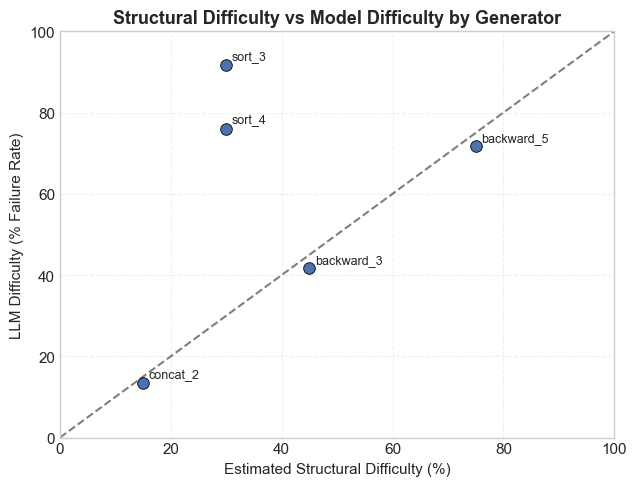


Structural vs Model Difficulty Summary:
 Generator  LLM Difficulty (%)  Estimated Structural Difficulty (%)
backward_5           71.666667                                   75
backward_7           93.888889                                  105
backward_3           41.666667                                   45
    sort_4           76.000000                                   30
  concat_2           13.333333                                   15
    sort_3           91.666667                                   30


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Construct comparison data
# -----------------------------
comparison_data = []

for gen, stats in gen_stats.items():
    llm_difficulty = 100 - (stats['correct'] / stats['total'] * 100)

    # Structural (human-oriented) difficulty heuristic
    human_difficulty = human_difficulty_factors.get(gen, 5) * 15

    comparison_data.append({
        'Generator': gen,
        'LLM Difficulty (%)': llm_difficulty,
        'Estimated Structural Difficulty (%)': human_difficulty
    })

comp_df = pd.DataFrame(comparison_data)

# -----------------------------
# Visualization
# -----------------------------
fig, ax = plt.subplots(figsize=(6.5, 5))

ax.scatter(
    comp_df['Estimated Structural Difficulty (%)'],
    comp_df['LLM Difficulty (%)'],
    s=70,
    color='#4C72B0',
    edgecolor='black',
    linewidth=0.6
)

# Diagonal reference
ax.plot([0, 100], [0, 100], linestyle='--', color='black', alpha=0.5)

# Labels
for _, row in comp_df.iterrows():
    ax.annotate(
        row['Generator'],
        (row['Estimated Structural Difficulty (%)'],
         row['LLM Difficulty (%)']),
        textcoords='offset points',
        xytext=(4, 4),
        fontsize=9
    )

ax.set_xlabel('Estimated Structural Difficulty (%)')
ax.set_ylabel('LLM Difficulty (% Failure Rate)')
ax.set_title('Structural Difficulty vs Model Difficulty by Generator', fontsize=13)

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(
    '../results/structural_vs_model_difficulty.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()

# -----------------------------
# Table (exact values)
# -----------------------------
print("\nStructural vs Model Difficulty Summary:")
print(comp_df.to_string(index=False))


In [24]:
# Summary statistics
print("\n📊 Summary by Category")
print("="*80)
summary_df = pd.DataFrame([
    {'Category': 'Easy Human / Hard LLM', 'Example': 'sort_3, sort_4', 
     'LLM Success': '8-24%', 'Key Factor': 'Requires iteration recognition'},
    {'Category': 'Easy for Both', 'Example': 'concat_2', 
     'LLM Success': '87%', 'Key Factor': 'Direct pattern match'},
    {'Category': 'Hard for Both', 'Example': 'backward_7', 
     'LLM Success': '6%', 'Key Factor': 'Long chains + distractors'},
    {'Category': 'Medium for Both', 'Example': 'backward_3, backward_5', 
     'LLM Success': '28-58%', 'Key Factor': 'Moderate planning needed'},
])
print(summary_df.to_string(index=False))
print("\nFor detailed analysis and findings, see: report/Human vs Machine.md")



📊 Summary by Category
             Category                Example LLM Success                     Key Factor
Easy Human / Hard LLM         sort_3, sort_4       8-24% Requires iteration recognition
        Easy for Both               concat_2         87%           Direct pattern match
        Hard for Both             backward_7          6%      Long chains + distractors
      Medium for Both backward_3, backward_5      28-58%       Moderate planning needed

For detailed analysis and findings, see: report/Human vs Machine.md
